Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
sns.set_theme(style="whitegrid")


Load Dataset

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Explore Data

In [3]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())


Shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.

Data Cleaning

In [4]:
# No missing data; renaming columns for clarity
df.columns = [col.replace(" (cm)", "").replace(" ", "_") for col in df.columns]


Analysis with NumPy & Pandas

In [5]:
avg_sepal_length = np.mean(df['sepal_length'])
print("Average Sepal Length:", avg_sepal_length)

species_mean = df.groupby('species')['sepal_length'].mean()
print("Mean Sepal Length by Species:\n", species_mean)


Average Sepal Length: 5.843333333333334
Mean Sepal Length by Species:
 species
0    5.006
1    5.936
2    6.588
Name: sepal_length, dtype: float64


Visualization with Matplotlib

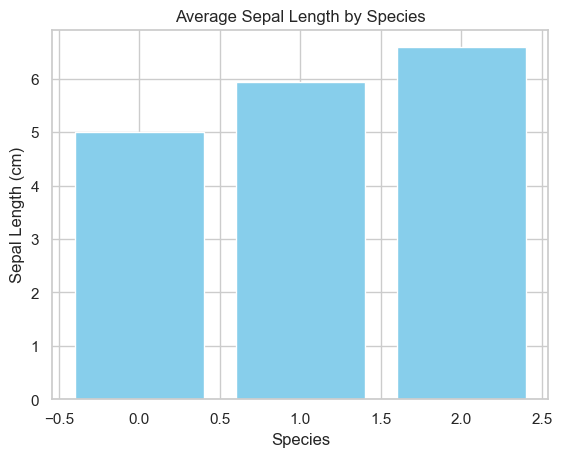

In [6]:
species = species_mean.index
values = species_mean.values

plt.bar(species, values, color='skyblue')
plt.title("Average Sepal Length by Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length (cm)")
plt.show()


Visualization with Seaborn

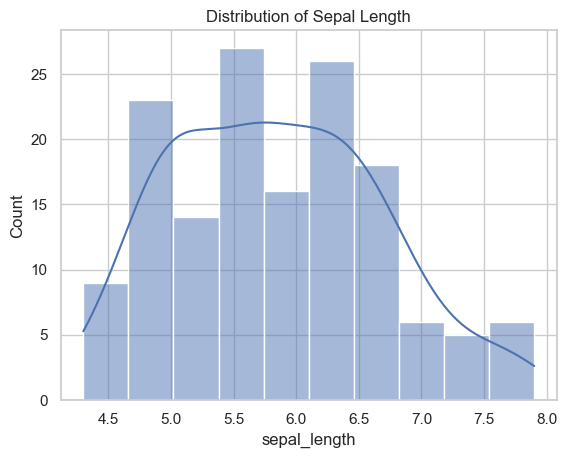

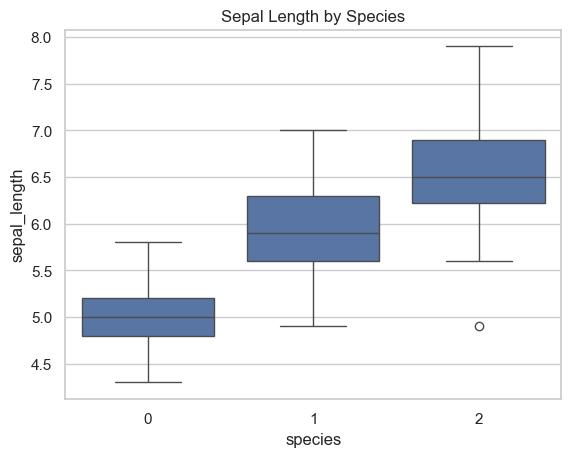

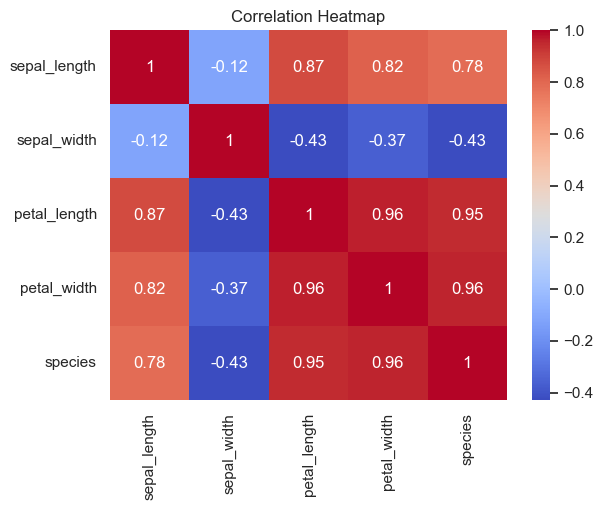

In [7]:
sns.histplot(df['sepal_length'], bins=10, kde=True)
plt.title("Distribution of Sepal Length")
plt.show()

sns.boxplot(x='species', y='sepal_length', data=df)
plt.title("Sepal Length by Species")
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
